In [4]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [6]:
PROJECT_ROOT = Path.cwd().parents[1]

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "BTCUSDT"
    / "BTCUSDT_1m_baseline.csv"
)

df = pd.read_csv(DATA_PATH)

df.head()

,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,target,hour,minute,day_of_week
0,93576.00,93610.93,93537.50,93610.93,8.21827,7.689788e+05,2631,3.95157,369757.326529,1,0,0,2
1,93610.93,93652.00,93606.20,93652.00,12.14029,1.136551e+06,1273,4.08887,382791.500172,1,0,1,2
2,93652.00,93702.15,93635.98,93702.15,11.60597,1.087101e+06,1095,5.86840,549682.868570,0,0,2,2
3,93702.14,93702.15,93654.48,93677.98,8.72958,8.177203e+05,1461,2.48203,232486.113080,0,0,3,2
4,93677.98,93677.99,93659.92,93661.20,5.24749,4.915570e+05,988,0.48880,45786.251963,1,0,4,2


In [7]:
print(df.shape)

df.info()

df.describe()

(20160, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20160 entries, 0 to 20159
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   open                    20160 non-null  float64
 1   high                    20160 non-null  float64
 2   low                     20160 non-null  float64
 3   close                   20160 non-null  float64
 4   volume                  20160 non-null  float64
 5   quote_asset_volume      20160 non-null  float64
 6   number_of_trades        20160 non-null  int64  
 7   taker_buy_base_volume   20160 non-null  float64
 8   taker_buy_quote_volume  20160 non-null  float64
 9   target                  20160 non-null  int64  
 10  hour                    20160 non-null  int64  
 11  minute                  20160 non-null  int64  
 12  day_of_week             20160 non-null  int64  
dtypes: float64(8), int64(5)
memory usage: 2.0 MB


,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,target,hour,minute,day_of_week
count,20160.000000,20160.000000,20160.000000,20160.000000,20160.000000,2.016000e+04,20160.000000,20160.000000,2.016000e+04,20160.000000,20160.000000,20160.000000,20160.00000
mean,96061.065091,96091.716962,96030.918949,96061.208369,15.270832,1.460213e+06,2464.067312,7.302775,6.987497e+05,0.480952,11.500000,29.500000,3.00000
std,2443.366006,2437.108662,2449.238027,2443.308985,26.560932,2.520571e+06,2576.195324,13.227869,1.264571e+06,0.499649,6.922358,17.318532,2.00005
min,89417.870000,90172.490000,89256.690000,89417.880000,0.193000,1.825471e+04,78.000000,0.033300,3.148225e+03,0.000000,0.000000,0.000000,0.00000
25%,94305.272500,94333.330000,94280.000000,94305.530000,3.705470,3.571641e+05,823.000000,1.358615,1.305633e+05,0.000000,5.750000,14.750000,1.00000
50%,95409.970000,95452.715000,95358.455000,95410.585000,7.722920,7.431454e+05,1587.000000,3.391310,3.260565e+05,0.000000,11.500000,29.500000,3.00000
75%,97858.932500,97875.345000,97843.190000,97858.937500,16.707380,1.602332e+06,3252.500000,8.014920,7.712846e+05,1.000000,17.250000,44.250000,5.00000
max,102687.210000,102724.380000,102490.000000,102687.210000,771.795850,7.246185e+07,41159.000000,355.077880,3.390061e+07,1.000000,23.000000,59.000000,6.00000


In [8]:
def create_target(df):
    """
    Tạo target:
    1 = Close > Open (Bullish)
    0 = Close <= Open (Bearish)
    """
    df = df.copy()

    df["target"] = np.where(
        df["close"] > df["open"],
        1,
        0
    )

    return df

In [11]:
df = create_target(df)

df.head()

,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,target,hour,minute,day_of_week
0,93576.00,93610.93,93537.50,93610.93,8.21827,7.689788e+05,2631,3.95157,369757.326529,1,0,0,2
1,93610.93,93652.00,93606.20,93652.00,12.14029,1.136551e+06,1273,4.08887,382791.500172,1,0,1,2
2,93652.00,93702.15,93635.98,93702.15,11.60597,1.087101e+06,1095,5.86840,549682.868570,1,0,2,2
3,93702.14,93702.15,93654.48,93677.98,8.72958,8.177203e+05,1461,2.48203,232486.113080,0,0,3,2
4,93677.98,93677.99,93659.92,93661.20,5.24749,4.915570e+05,988,0.48880,45786.251963,0,0,4,2


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20160 entries, 0 to 20159
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   open                    20160 non-null  float64
 1   high                    20160 non-null  float64
 2   low                     20160 non-null  float64
 3   close                   20160 non-null  float64
 4   volume                  20160 non-null  float64
 5   quote_asset_volume      20160 non-null  float64
 6   number_of_trades        20160 non-null  int64  
 7   taker_buy_base_volume   20160 non-null  float64
 8   taker_buy_quote_volume  20160 non-null  float64
 9   target                  20160 non-null  int64  
 10  hour                    20160 non-null  int64  
 11  minute                  20160 non-null  int64  
 12  day_of_week             20160 non-null  int64  
dtypes: float64(8), int64(5)
memory usage: 2.0 MB


In [14]:
X = df.drop(columns="target")
y = df["target"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (20160, 12)
y shape: (20160,)


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (16128, 12)
Test : (4032, 12)


In [ ]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [18]:
y_pred = model.predict(X_test)

In [27]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8661
Precision: 0.8954
Recall   : 0.8169
F1 Score : 0.8544


In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.88      2093
           1       0.90      0.82      0.85      1939

    accuracy                           0.87      4032
   macro avg       0.87      0.86      0.87      4032
weighted avg       0.87      0.87      0.87      4032



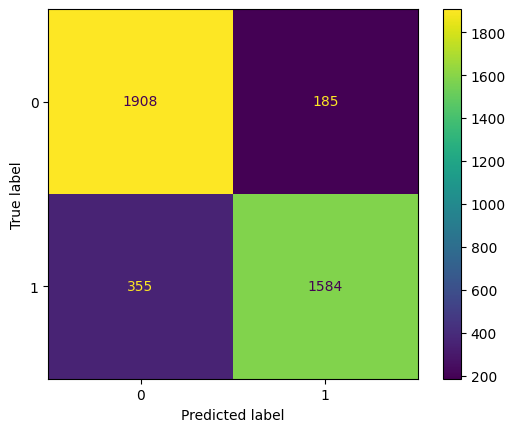

In [25]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [23]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
})

coef_df["abs_coef"] = coef_df["coefficient"].abs()

coef_df.sort_values(
    by="abs_coef",
    ascending=False
)

,feature,coefficient,abs_coef
3,close,29.509893,29.509893
0,open,-29.285052,29.285052
8,taker_buy_quote_volume,1.961107,1.961107
5,quote_asset_volume,-1.416437,1.416437
4,volume,-1.269313,1.269313
7,taker_buy_base_volume,0.867977,0.867977
2,low,-0.699560,0.699560
1,high,0.442530,0.442530
9,hour,0.074585,0.074585
10,minute,-0.037073,0.037073
